# Screening real materials with matverse

Materials screening is the problem of narrowing a large candidate list to a
small one you can afford to study properly. The narrowing is cheap and
approximate; the studying is expensive and exact; and almost all the difficulty
lies in keeping track of which is which.

matverse holds a screen in a single [AnnData](https://anndata.readthedocs.io/)
object. Structures, descriptors, computed properties and the record of what
produced them stay together, so a filtered dataset cannot silently point at the
wrong structure and a surrogate energy cannot be quietly averaged with a
first-principles one.

This notebook runs a screen end to end on published structures. It needs no
network, no API key and no downloaded model.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 212   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

`mv.datasets` ships real structures rather than cells built in code. The
crystallographic data comes from the set [pymatgen](https://pymatgen.org/)
distributes, so nothing is downloaded and the provenance is a package you
already have installed.

We use the olivine and NASICON cathodes:

- **LiFePO₄** — the olivine cathode of [Padhi et al.
  (1997)](https://doi.org/10.1149/1.1837571), the paper that made
  phospho-olivines a cathode class rather than a curiosity
- **NaFePO₄** — the sodium analogue of the same framework, the reason
  sodium-ion work keeps returning to olivines (Moreau et al., *Chem. Mater.*
  2010)
- **Li₃V₂(PO₄)₃** — a NASICON-framework cathode, a different way of building
  open channels out of phosphate polyanions (Yin et al., *J. Am. Chem. Soc.*
  2003)

Three materials is not a screen. It is enough to see what the object does with
them, which is what this page is for.

In [2]:
mv.datasets.available()

{'battery_cathodes': {'structures': ['LiFePO4', 'NaFePO4', 'Li3V2(PO4)3'],
  'description': 'Olivine and NASICON cathode materials. Li and Na analogues of the same framework sit side by side, so an intercalation comparison has something to compare.',
  'use_for': 'mv.neb migration barriers, mv.thermo.hull stability'},
 'solid_electrolytes': {'structures': ['Li10GeP2S12', 'Li2O', 'Li2O2'],
  'description': 'A superionic conductor and two simple lithium oxides. Li10GeP2S12 is the canonical fast-ion conductor and is 58 atoms, so it is also a realistic cost test.',
  'use_for': 'mv.md.conductivity, mv.neb.barrier'},
 'oxides': {'structures': ['SrTiO3', 'TiO2', 'VO2', 'BaNiO3', 'SiO2'],
  'description': 'Perovskite, rutile, and a metal-insulator transition compound. Spans wide-gap insulator to correlated metal.',
  'use_for': 'mv.prop.xrd, mv.thermo.hull, band gap screening'},
 'semiconductors': {'structures': ['Si', 'SiO2', 'TlBiSe2', 'Sn'],
  'description': 'Silicon and its oxide, a topol

In [3]:
md = mv.datasets.load("battery_cathodes")
md

AnnData object with n_obs × n_vars = 3 × 6
    obs: 'name', 'spacegroup', 'dataset', 'source'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is', 'dataset'
    obsm: 'structures'
    layers: None (.X)

`X` is the composition matrix and `var` is the periodic table. Neither was asked
for: composition is intrinsic to a material rather than derived from it, so both
are built at construction.

Materials × elements is the same shape as cells × genes — sparse, non-negative,
mostly zero — which is what lets the ordination and enrichment machinery apply
to chemical space without being rewritten.

In [4]:
pd.DataFrame(md.X.toarray(), index=md.obs["name"], columns=md.var_names)

element,Li,O,Na,P,V,Fe
name,,,,,,
LiFePO4,1.0,4.0,0.0,1.0,0.0,1.0
NaFePO4,0.0,4.0,1.0,1.0,0.0,1.0
Li3V2(PO4)3,3.0,12.0,0.0,3.0,2.0,0.0


In [5]:
md.var[["Z", "electronegativity", "period", "is_transition_metal"]]

,Z,electronegativity,period,is_transition_metal
element,,,,
Li,3.0,0.98,2.0,False
O,8.0,3.44,2.0,False
Na,11.0,0.93,3.0,False
P,15.0,2.19,3.0,False
V,23.0,1.63,4.0,True
Fe,26.0,1.83,4.0,True


Because `var` is the periodic table, the natural display of anything
element-indexed is the periodic table itself — here, how many of the three
cathodes each element appears in.

Text(0.5, 1.0, 'the chemistry of this library')

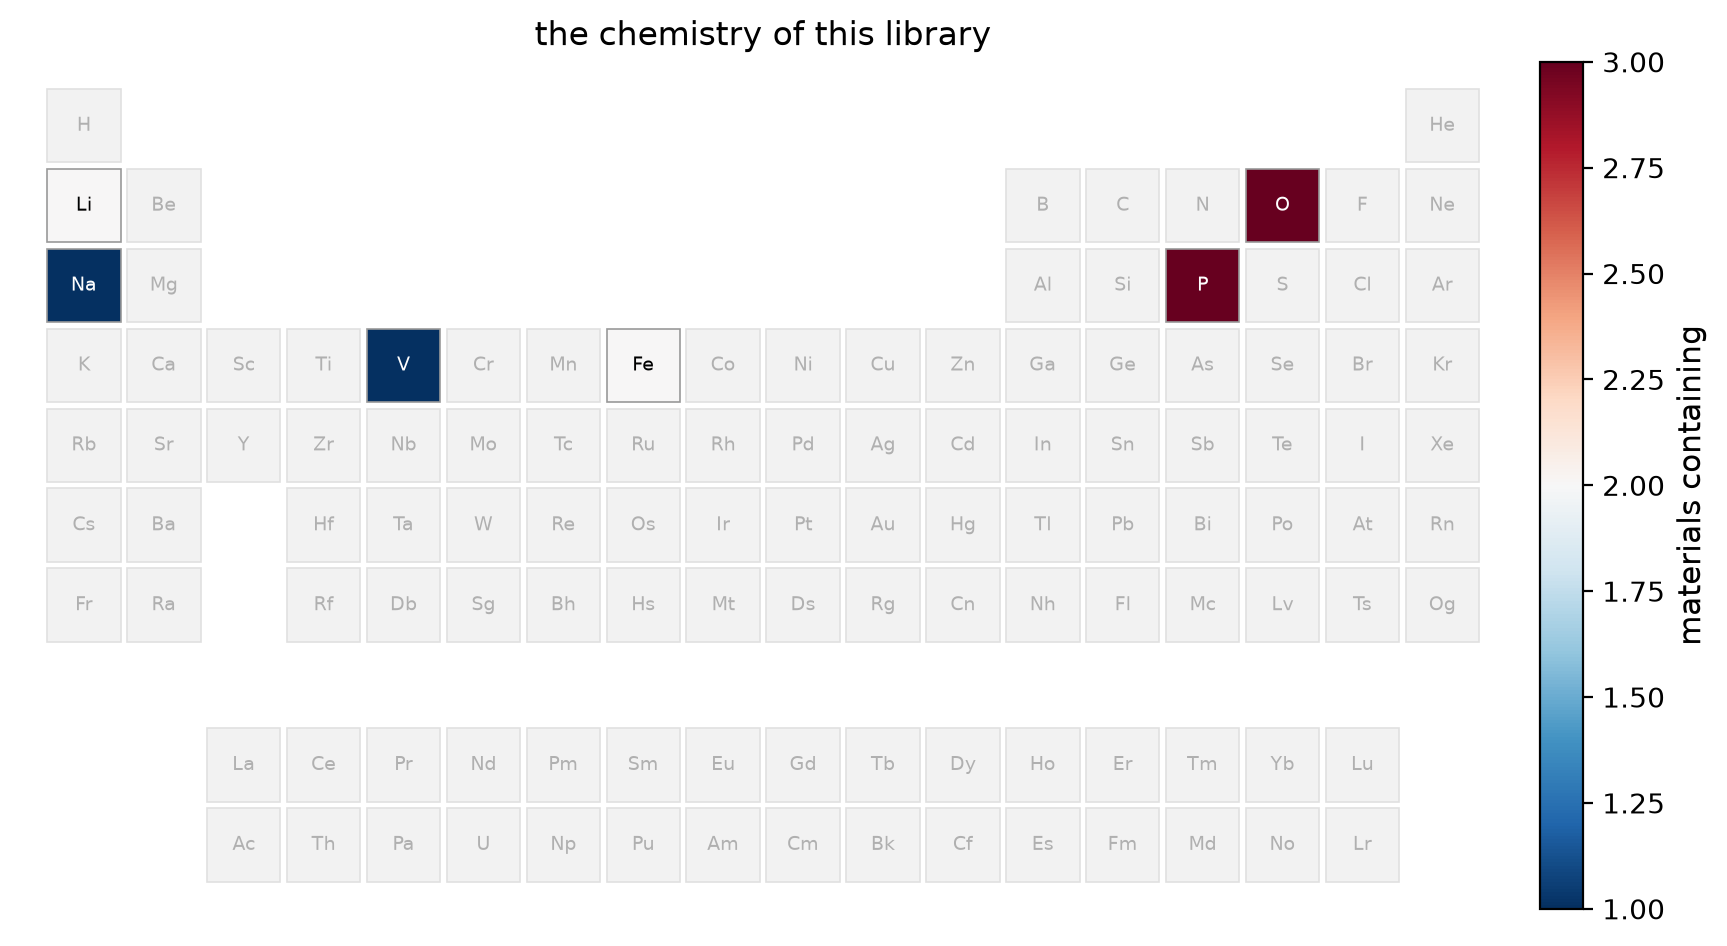

In [6]:
md.var["n_materials"] = (md.X > 0).sum(axis=0).A1

ax = mv.pl.periodic_table(md, color="n_materials", label="materials containing")
ax.set_title("the chemistry of this library")

And you can just look at one, which catches the mistakes a number will not
show you — a slab built upside down, a cell that came out of a parser inside
out.

Text(0.5, 1.0, 'LiFePO$_4$, projected along its thinnest axis')

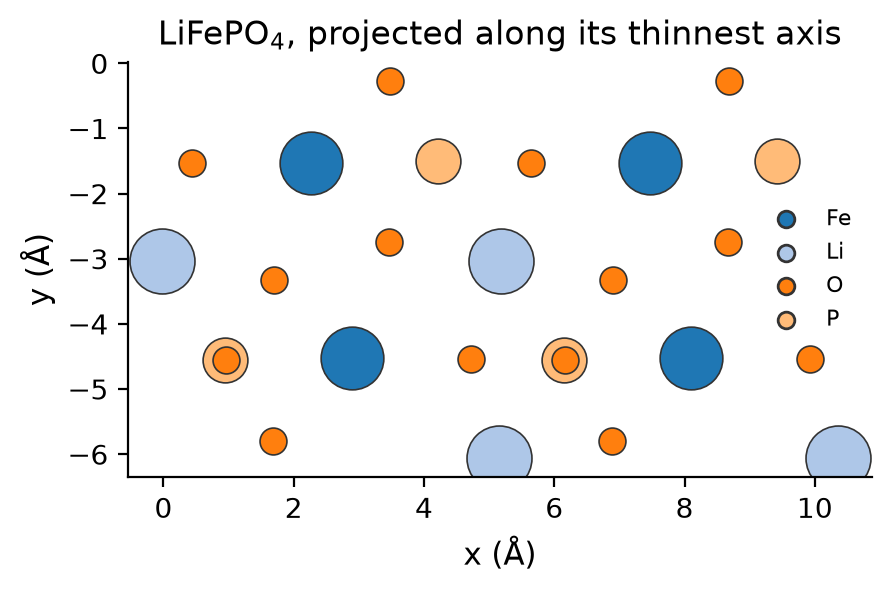

In [7]:
ax = mv.pl.structure(md, "LiFePO4", backend="matplotlib")
ax.set_title("LiFePO$_4$, projected along its thinnest axis")

With `py3Dmol` installed the default backend is an interactive viewer instead.
Neither replaces VESTA for real inspection — this is the quick look you take
twenty times a day.

Counts come from the **reduced** formula, so a supercell and its primitive cell
occupy the same point in chemical space. Cell size lives in `obs['nsites']`.

## Describing and screening the structures

`mv.pp` is the preprocessing namespace, shaped after `scanpy.pp` because the
operations correspond: `qc` is `calculate_qc_metrics`, `filter_materials` is
`filter_cells`.

In [8]:
mv.pp.describe(md)
mv.pp.qc(md)

md.obs[["name", "spacegroup", "formula", "nsites", "density", "is_valid"]]

,name,spacegroup,formula,nsites,density,is_valid
0,LiFePO4,P2_1/c,LiFePO4,28,3.497400,True
1,NaFePO4,Pnma,NaFePO4,28,3.520424,True
2,Li3V2(PO4)3,C2,Li3V2(PO4)3,40,2.875413,True


In [9]:
mv.pp.prototype(md)
md.obs[["name", "spacegroup", "prototype_mineral", "strukturbericht"]]

,name,spacegroup,prototype_mineral,strukturbericht
0,LiFePO4,P2_1/c,,
1,NaFePO4,Pnma,,
2,Li3V2(PO4)3,C2,,


In [10]:
mv.pp.symmetry(md)
md.obs[["name", "crystal_system", "point_group", "n_wyckoff", "wyckoff"]]

,name,crystal_system,point_group,n_wyckoff,wyckoff
0,LiFePO4,monoclinic,2/m,8.0,"2a, 2b, 4e, 4e, 4e, 4e, 4e, 4e"
1,NaFePO4,orthorhombic,mmm,6.0,"4a, 4c, 4c, 4c, 4c, 8d"
2,Li3V2(PO4)3,monoclinic,2,22.0,"2c, 1b, 1a, 2c, 2c, 2c, 2c, 1b, 1a, 2c, 2c, 2c..."


In [11]:
mv.prop.frontier_orbitals(md)
md.obs[["name", "homo_element", "homo_orbital", "lumo_element",
        "lumo_orbital", "likely_metal"]]

,name,homo_element,homo_orbital,lumo_element,lumo_orbital,likely_metal
0,LiFePO4,Fe,3d,Fe,3d,True
1,NaFePO4,Fe,3d,Fe,3d,True
2,Li3V2(PO4)3,O,2p,O,2p,True


The cheapest possible statement about electronic structure: line up the atomic
orbital energies of the elements present, and see which sits highest occupied
and which lowest unoccupied. No calculator, no structure — only the composition.

What it tells you is **which element controls each band edge**, and that is a
real design handle. On SrTiO₃ it says O 2p and Ti 3d, the textbook perovskite
answer, and it says exactly the same for BaTiO₃ — which is why substituting on
the A site of a perovskite barely moves the gap and substituting on the B site
moves it a lot.

```{warning}
`orbital_gap_estimate` is a **difference of atomic orbital energies**, not a
band gap. No hybridisation, no crystal field, no Madelung potential, no
structure — two polymorphs get the same answer, and NaCl comes out near 6 eV
against a measured 8.5. Use it to sort a list before computing, never as a
number.

`likely_metal` is the more trustworthy column: "the frontier orbitals overlap"
survives a lot of approximation.
```

`spacegroup` gives the symbol. This gives what the symbol *implies* — and
`wyckoff` is the part worth reading.

Wyckoff positions say how many **distinct** sites a structure has, and that
number decides how much work everything downstream is: how many vacancies
`mv.pp.defects` will enumerate, how many NMR environments to expect, how many
independent parameters a refinement has. LiFePO₄ has eight, which is why the
defect tutorial gets six inequivalent vacancies out of a 28-atom cell rather
than twenty-eight.

Two structures in the same space group with different Wyckoff sets are
different structures.

A space group says which symmetries a structure has. A **prototype** says which
structure it *is* — and the two are not the same question: Fm-3m covers
rocksalt, face-centred cubic and half-Heusler alike, so a screen that groups by
space group puts them in one bin.

This is also what makes a generative model's output legible. "Novel composition
in a known prototype" and "novel prototype" are different claims, and the second
is rare.

An unmatched structure gets an empty string rather than a guess — the AFLOW
library is large but finite, and "not in it" is worth keeping distinct from a
wrong label.

`spacegroup` is determined from the deposited coordinates, not copied from a
label — which is why LiFePO₄ comes out as P2₁/c rather than the Pnma the olivine
is usually reported in. The framework is the same; the cell in this file is a
lower-symmetry setting of it. `mv.pp.standardize` puts both into a conventional
cell when that matters.

That is the point of shipping published structures rather than a cubic cell
someone typed in: the awkwardness is real and you would meet it anyway.

## Simulating diffraction patterns

`mv.prop.xrd` needs no calculator, so it is the first real property available for
any structure. Peaks are broadened onto a shared 2θ grid, because a peak list
cannot be compared across materials — no two share peak positions.

In [12]:
mv.prop.xrd(md, two_theta=(10, 60), step=0.02)

md.obsm["xrd_calc"].shape

(3, 2501)

Text(0.5, 1.0, 'simulated powder patterns, Cu Kα')

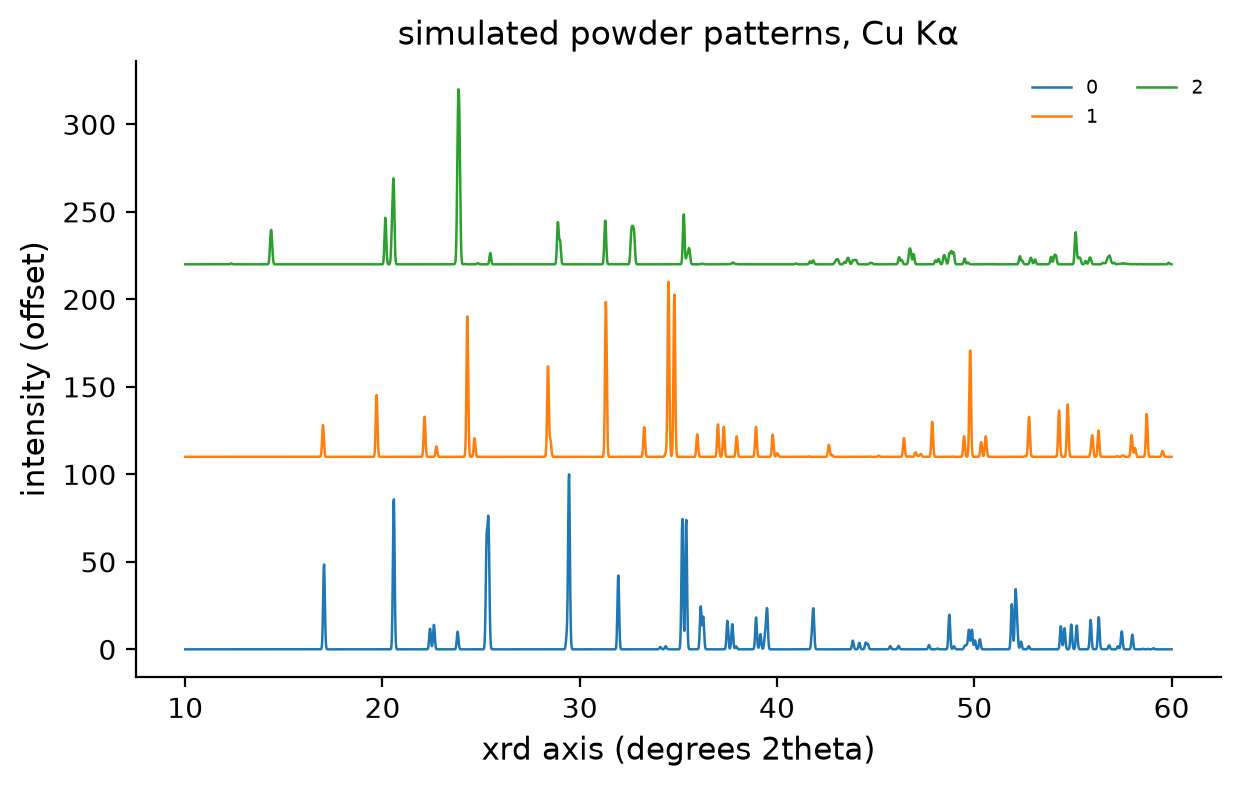

In [13]:
ax = mv.pl.spectra(md, "xrd", rows=[0, 1, 2], offset=110)
ax.set_title("simulated powder patterns, Cu Kα")

LiFePO₄ and NaFePO₄ are the same framework with a different alkali, and the
patterns show it: the same families of reflections, shifted.

## Identifying a phase

Feed one pattern back as though it had been measured, and ask which candidate it
is. This is phase identification against the library you already have.

In [14]:
measured = md.obsm["xrd_calc"][1]
mv.exp.match_xrd(md, measured, mv.grid_of(md, "xrd"))

md.obs[["name", "xrd_match", "xrd_match_rank"]].sort_values("xrd_match_rank")

,name,xrd_match,xrd_match_rank
1,NaFePO4,1.000000,1.0
2,Li3V2(PO4)3,0.062813,2.0
0,LiFePO4,0.046845,3.0


Row 1 comes back at 1.00 and the runner-up at 0.06, which is the margin you want
— NaFePO₄ and LiFePO₄ share a framework, so a scoring function that could not
tell them apart would be no use on the cases that matter.

```{warning}
`match_xrd` scores against the candidates in **this object** and nothing else,
and records that in `uns['xrd_match']['scored_against']`. A high score means
"the best of what you gave it", not "identified" — the true phase can be absent
from your library entirely.
```

## Choosing a calculator

Energies need a calculator, and which one is part of the result rather than an
implementation detail. `mv.calc.available()` reports what this installation can
run.

In [15]:
mv.calc.available()["emt"]

{'kind': 'classical',
 'method': 'EMT',
 'reference': None,
 'surrogate': True,
 'license': 'LGPL-2.1',
 'uncertainty': None,
 'note': 'ASE effective-medium theory. Parameterised only for Al Cu Ag Au Ni Pd Pt H C N O — enough to exercise a pipeline, not enough to screen with.'}

ASE's effective-medium theory is the only calculator matverse ships working. It
is parameterised for Al, Cu, Ag, Au, Ni, Pd, Pt, H, C, N and O — which excludes
the Fe, P and V in the cathodes above.

That is a real constraint, not a tutorial convenience, so the screen switches to
materials EMT can run. For anything else, register a machine-learned potential.
The factory is lazy — it is not called until something runs at that level — so
the registration itself works whether or not the package is installed:

In [16]:
def mace_factory():
    "Imported only when a calculation actually asks for this level."
    from mace.calculators import mace_mp
    return mace_mp(model="medium-mpa-0")

mv.calc.register_calculator("mace-mpa", mace_factory,
                            kind="mlip", method="MACE-MPA-0",
                            reference="PBE+U", license="MIT")

mv.calc.available()["mace-mpa"]

{'kind': 'mlip',
 'method': 'MACE-MPA-0',
 'reference': 'PBE+U',
 'surrogate': True,
 'license': 'MIT',
 'uncertainty': None}

Registered, with its provenance attached — the method, the level of theory it
reproduces, and the licence. That last one is not decoration: `mv.check_commercial_use`
reads it, and a screen assembled from levels nobody recorded is one you cannot
publish from.

Running at that level is what would need MACE installed.

In [17]:
metals = mv.datasets.metals()
metals.obs[["name", "lattice_parameter"]]

,name,lattice_parameter
0,Al,4.0495
1,Cu,3.6149
2,Ni,3.5240
3,Ag,4.0853
4,Au,4.0782
5,Pd,3.8907
6,Pt,3.9242


Published room-temperature lattice parameters for the seven face-centred cubic
metals. Relax them:

In [18]:
mv.pp.describe(metals)
mv.calc.relax(metals, level="emt", fmax=0.02)

metals.obs[["name", "energy_per_atom_emt", "relax_converged_emt"]]

,name,energy_per_atom_emt,relax_converged_emt
0,Al,-0.004882,True
1,Cu,-0.007036,True
2,Ni,-0.013304,True
3,Ag,-0.000366,True
4,Au,-0.000134,True
5,Pd,-0.000270,True
6,Pt,-0.000150,True


In [19]:
mv.variants(metals)

['input', 'relaxed_emt']

The relaxed geometry becomes its own **variant** rather than replacing the
input, so "which structure was this energy computed on" stays answerable from
the object alone.

## Computing properties

Elastic constants by finite strain, phonons by frozen displacement, and thermal
conductivity from both.

In [20]:
mv.prop.elastic(metals, level="emt", source="relaxed_emt")
mv.prop.phonon(metals, level="emt", source="relaxed_emt", supercell=(1, 1, 1))
mv.prop.thermal_conductivity(metals, level="emt")

metals.obs[["name", "bulk_modulus_emt", "debye_temperature_emt",
            "thermal_conductivity_emt", "dynamically_stable_emt"]].round(1)

,name,bulk_modulus_emt,debye_temperature_emt,thermal_conductivity_emt,dynamically_stable_emt
0,Al,39.7,420.2,8.3,True
1,Cu,134.8,404.6,11.3,True
2,Ni,175.7,532.6,28.2,True
3,Ag,100.4,254.3,4.4,True
4,Au,174.3,175.6,1.4,True
5,Pd,179.4,292.6,4.9,True
6,Pt,278.4,224.5,3.0,True


Worth comparing against measured values rather than accepting:

| | EMT | experiment |
|---|---|---|
| bulk modulus, Cu | 135 | 140 GPa |
| bulk modulus, Ni | 176 | 180 GPa |
| bulk modulus, Ag | 100 | 101 GPa |
| bulk modulus, Al | 40 | 76 GPa |
| Debye temperature, Au | 176 | 165 K |
| Debye temperature, Ag | 254 | 225 K |
| Debye temperature, Al | 420 | 428 K |

Good for the transition metals EMT was fitted to, and a factor of two out on
aluminium's bulk modulus. That is the shape of the error a cheap potential
makes, and the reason a screen ranked on it is a shortlist rather than an
answer.

```{note}
Before v0.1.17 the copper entry read 123 GPa and the nickel entry 157. The
difference is not a better potential: `mv.calc.relax` moved only the atomic
positions, and the forces on an fcc metal vanish by symmetry, so nothing moved
at all and every one of these properties was computed at the published
room-temperature lattice parameter rather than at EMT's own minimum. Relaxing
the cell moved five of the seven metals closer to experiment. Aluminium did not
move much, because EMT's aluminium is wrong for a different reason.
```

The conductivities look far too small next to the 400 W/m/K a copper wire is
sold on — but `mv.prop.thermal_conductivity` returns the **lattice**
contribution from the Slack model, and in a metal almost all the heat is carried
by electrons. A few W/m/K is the right magnitude for the phonons alone.

Every phonon mode is real, so all seven are dynamically stable, as elemental fcc
metals at their equilibrium lattice parameter should be. That check matters
because a composition can sit on the convex hull and still be a structure that
will not hold together.

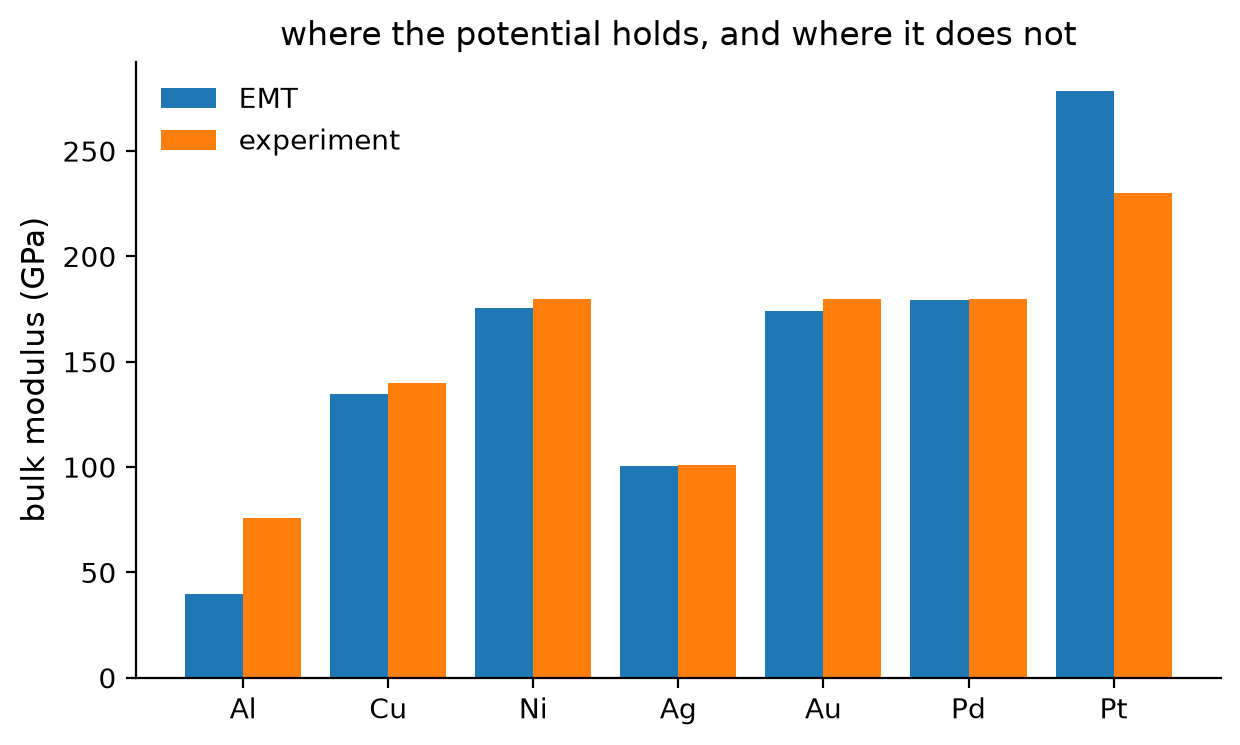

In [21]:
import matplotlib.pyplot as plt

measured = {"Al": 76, "Cu": 140, "Ni": 180, "Ag": 101, "Au": 180,
            "Pd": 180, "Pt": 230}
names = list(metals.obs["name"])
predicted = metals.obs["bulk_modulus_emt"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(names))
ax.bar(x - 0.2, predicted, 0.4, label="EMT")
ax.bar(x + 0.2, [measured[n] for n in names], 0.4, label="experiment")
ax.set_xticks(x, names)
ax.set_ylabel("bulk modulus (GPa)")
ax.set_title("where the potential holds, and where it does not")
ax.legend()

Aluminium is the outlier, platinum is high, and the middle five track closely.
A plot makes that visible in a way the table does not — EMT is not uniformly
wrong, it is wrong about particular elements, which is a different thing to
know.

## Two routes to the same number

A bulk modulus is a curvature. `mv.prop.elastic` takes it in strain, from the
stiffness tensor; `mv.prop.eos` takes it in volume, by compressing the cell and
fitting an equation of state. They are the same quantity, so they have to
agree — and because both live on the same object, checking is a subtraction.

In [22]:
mv.prop.eos(metals, level="emt", source="relaxed_emt")

comparison = metals.obs[["name", "bulk_modulus_emt", "bulk_modulus_eos_emt",
                         "bulk_modulus_derivative_emt",
                         "equilibrium_volume_emt"]].round(2)
comparison["disagreement_%"] = (
    100 * (comparison["bulk_modulus_eos_emt"] - comparison["bulk_modulus_emt"])
    / comparison["bulk_modulus_emt"]).round(2)
comparison

,name,bulk_modulus_emt,bulk_modulus_eos_emt,bulk_modulus_derivative_emt,equilibrium_volume_emt,disagreement_%
0,Al,39.73,39.30,1.95,63.73,-1.08
1,Cu,134.77,134.37,4.19,46.26,-0.30
2,Ni,175.74,174.40,2.98,42.40,-0.76
3,Ag,100.36,100.09,4.71,67.10,-0.27
4,Au,174.30,173.72,5.36,66.73,-0.33
5,Pd,179.43,179.04,4.89,58.35,-0.22
6,Pt,278.44,277.86,5.15,60.32,-0.21


Within 1.1% across seven metals and two independent implementations, and under
0.4% for six of them.

That agreement is worth more as a diagnostic than as a reassurance. While
`mv.calc.relax` was leaving the cell alone, these two columns differed by 9–12%
and always in the same direction — the stiffness was being measured about a
geometry under residual tensile stress, which softens it. Neither number looked
wrong on its own. **The disagreement was the only visible symptom**, and it was
visible only because both quantities sit on one object under names that say what
they are.

`mv.prop.eos` also returns what the elastic route cannot: the pressure
derivative `B0'`, near 4 for most solids, and the equilibrium volume read off
the fitted curve rather than off the optimiser.

Aluminium's `B0'` comes out at 1.95 against a measured 4.4. Taken with a bulk
modulus half the experimental value, that says EMT has the wrong *shape* for
aluminium's energy–volume curve rather than merely the wrong curvature at one
point — which is more than the bulk modulus alone could tell you.

The curves themselves are an `obsm` block on a shared scale-factor grid, so
they plot like any other curve.

Text(0.5, 1.0, 'energy-volume curves')

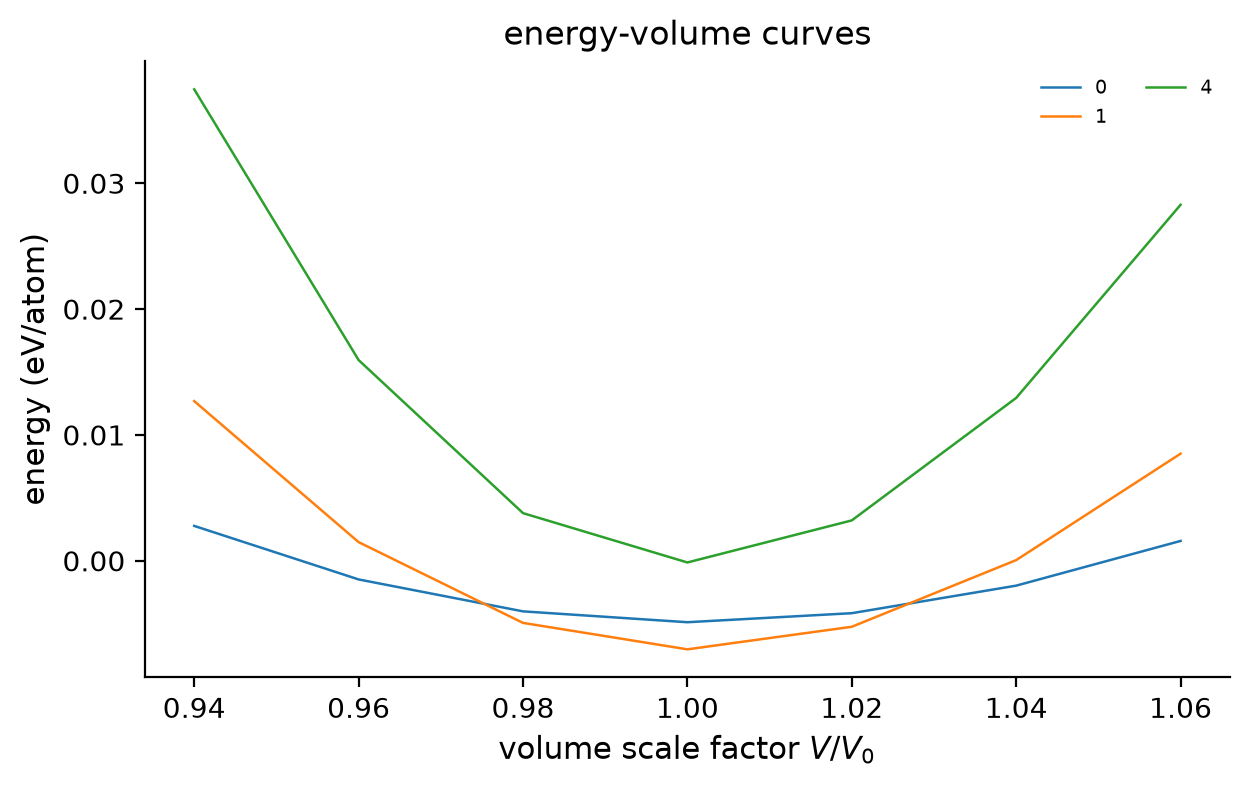

In [23]:
ax = mv.pl.spectra(metals, "eos", levels=("emt",), rows=[0, 1, 4])
ax.set_xlabel("volume scale factor $V/V_0$")
ax.set_ylabel("energy (eV/atom)")
ax.set_title("energy-volume curves")

## Off the zero-kelvin hull

A hull at 0 K is a hull at 0 K. `mv.prop.quasiharmonic` reuses that same
energy-volume curve to get to finite temperature: the Debye model supplies a
vibrational free energy at each volume, and the Gibbs free energy is minimised
over volume at every temperature. The cell expands because the minimum
moves.

In [24]:
mv.prop.quasiharmonic(metals, level="emt", source="relaxed_emt",
                      t_max=900, poisson=0.34)

metals.obs[["name", "thermal_expansion_qha_emt", "gruneisen_emt",
            "debye_temperature_qha_emt"]].round(6)

,name,thermal_expansion_qha_emt,gruneisen_emt,debye_temperature_qha_emt
0,Al,0.000058,0.940117,372.817415
1,Cu,0.000045,1.911467,474.676676
2,Ni,0.000025,1.320898,570.719716
3,Ag,0.000051,2.166536,295.573278
4,Au,0.000034,2.500457,288.484317
5,Pd,0.000033,2.270330,407.440406
6,Pt,0.000022,2.404330,372.861639


| volumetric expansion, /K | matverse | experiment |
|---|---|---|
| Cu | 4.5e-5 | 5.0e-5 |
| Ag | 5.1e-5 | 5.7e-5 |
| Al | 4.9e-5 | 6.9e-5 |

```{warning}
That column is **not** what pymatgen's `QuasiharmonicDebyeApprox` reports for
the optimum volume. Its Gruneisen parameter is right — 1.91 for copper against
a measured 1.96 — but the volume minimum it finds moves twelve times too
little, giving 4.3e-6 /K for copper.

`mv.prop.quasiharmonic` computes the expansion from the thermodynamic identity
instead:

$$\alpha_V = \frac{\gamma\, C_V}{B\, V}$$

with the model's own Gruneisen parameter, the bulk modulus fitted from the same
E(V) points, and the Debye heat capacity. That is the version that agrees with
experiment.

The disagreement was findable because `B` from `mv.prop.eos` and `gamma` from
the Debye model sit on one object under names that say what they are — the same
reason the relaxation bug two sections up was findable.
```

Text(0.5, 1.0, 'phonon density of states')

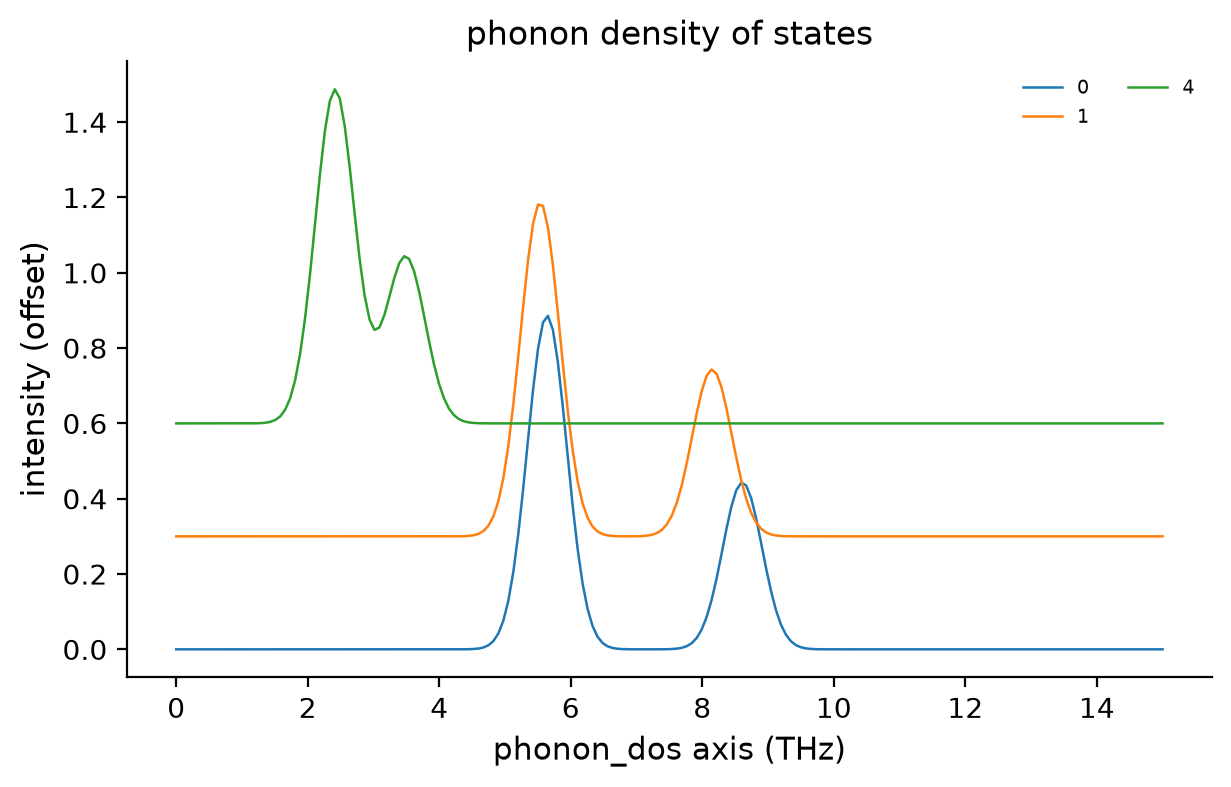

In [25]:
ax = mv.pl.spectra(metals, "phonon_dos", levels=("emt",), rows=[0, 1, 4],
                   offset=0.3)
ax.set_title("phonon density of states")

The phonons are also everything thermodynamics needs. `mv.prop.free_energy`
integrates the density of states into a vibrational free energy and entropy at
a temperature you name — the term that decides which polymorph wins when two
sit within a few meV at zero kelvin.

In [26]:
mv.prop.free_energy(metals, level="emt", temperature=300.0)

metals.obs[["name", "vibrational_free_energy_emt",
            "vibrational_entropy_emt"]].round(4)

,name,vibrational_free_energy_emt,vibrational_entropy_emt
0,Al,0.0066,0.0003
1,Cu,0.0040,0.0003
2,Ni,0.0278,0.0002
3,Ag,-0.0342,0.0004
4,Au,-0.0641,0.0005
5,Pd,-0.0227,0.0003
6,Pt,-0.0442,0.0004


### The q-points a supercell cannot hold

Everything above came from `method="commensurate"`: displace every atom of a
supercell, read the forces, diagonalise. It needs nothing beyond ASE, and it
samples only the q-points commensurate with the supercell — eight of them for a
2x2x2.

`method="phonopy"` fits force constants to the same displacements and
interpolates them onto an arbitrary mesh. It is both more accurate and much
cheaper, because symmetry collapses the displacement list: on fcc copper at
3x3x3, 162 central-difference force calls become **one** inequivalent
displacement, and the 300 K vibrational free energy goes from -13.1 meV/atom
(commensurate 2x2x2) to -17.4, against a converged -17.3. A commensurate 4x4x4
costing 384 force calls still only reaches -15.7. Those figures are for an
ideal a = 3.61 A cell — a convergence sequence needs a fixed geometry — so they
do not match the table below, which uses each metal's own EMT-relaxed cell.

Four meV/atom is the order a hull decision turns on, so this is not a rounding
detail. The default is nevertheless `"commensurate"`, because an answer that
silently changed depending on whether phonopy happened to be installed would be
worse than one that is merely coarse — `uns["grids"]` records which method
produced a stored spectrum.

In [27]:
try:
    import phonopy  # noqa: F401
    for method in ("commensurate", "phonopy"):
        mv.prop.phonon(metals, level="emt", source="relaxed_emt",
                       supercell=(2, 2, 2), method=method)
        mv.prop.free_energy(metals, level="emt", temperature=300.0)
        metals.obs[f"F_{method}"] = metals.obs["vibrational_free_energy_emt"]
    print(metals.obs[["name", "F_commensurate", "F_phonopy"]].round(5))
except ImportError:
    print("phonopy is not installed; pip install matverse[phonons]")

  name  F_commensurate  F_phonopy
0   Al        -0.00873   -0.01249
1   Cu        -0.01074   -0.01404
2   Ni         0.01208    0.00853
3   Ag        -0.04766   -0.05067
4   Au        -0.07595   -0.07817
5   Pd        -0.03572   -0.03848
6   Pt        -0.05605   -0.05836


Interpolation is also the only way to get a *dispersion*. A supercell holds a
finite set of q-points and a dispersion is the continuous line between them, so
`mv.prop.dispersion` needs phonopy and seekpath — the latter supplies the
high-symmetry path.

It returns a **bands-axis object** with the same layout `mv.elec.bands` uses for
electronic bands: one row per branch, a normalised path coordinate for columns.
That is why `mv.pl.bands` plots it unchanged.

In [28]:
from pymatgen.core import Lattice, Structure

# fcc copper, which is what copper is, and bcc copper, which is not.
both = mv.data.from_structures([
    Structure(Lattice([[0, 1.805, 1.805], [1.805, 0, 1.805],
                       [1.805, 1.805, 0]]), ["Cu"], [[0, 0, 0]]),
    Structure(Lattice.cubic(2.9), ["Cu", "Cu"], [[0, 0, 0], [.5, .5, .5]]),
])
both.obs_names = ["fcc-Cu", "bcc-Cu"]

try:
    ph = mv.prop.dispersion(both, level="emt", supercell=(3, 3, 3))
    print(ph.obs.groupby("material", observed=True)
          .agg(lowest=("branch_minimum", "min"),
               highest=("branch_maximum", "max"),
               unstable=("is_imaginary", "any")).round(3))
except ImportError:
    print("needs phonopy and seekpath; pip install matverse[phonons]")

          lowest  highest  unstable
material                           
bcc-Cu    -1.206    7.165      True
fcc-Cu     0.000    7.836     False


That is the check a hull cannot make, and the reason the two cells above are
fcc and bcc copper rather than the metals list: both sit at a perfectly ordinary
energy, and only one of them is a structure that holds together. `is_imaginary`
flags a branch that dips below zero *anywhere* on the path — bcc copper's goes
to about -1.2 THz partway along, which a Gamma-point calculation never sees.

The other thing to read off it is the acoustic branches, which must go to zero
at Gamma because the translational sum rule says so. A few hundredths of a THz
there is numerical; a whole THz means the structure was never relaxed.

Both are visible when it is drawn — by `mv.pl.bands`, the same function that
plots electronic bands, because it is the same axis. The two get their own
panels rather than being overlaid, because they share the abscissa without
sharing the path: fraction 0.33 is U|K for fcc and N for bcc, and one set of
tick labels across both would be wrong for one of them. `uns["path_labels"]`
holds the ticks per material for exactly that reason.

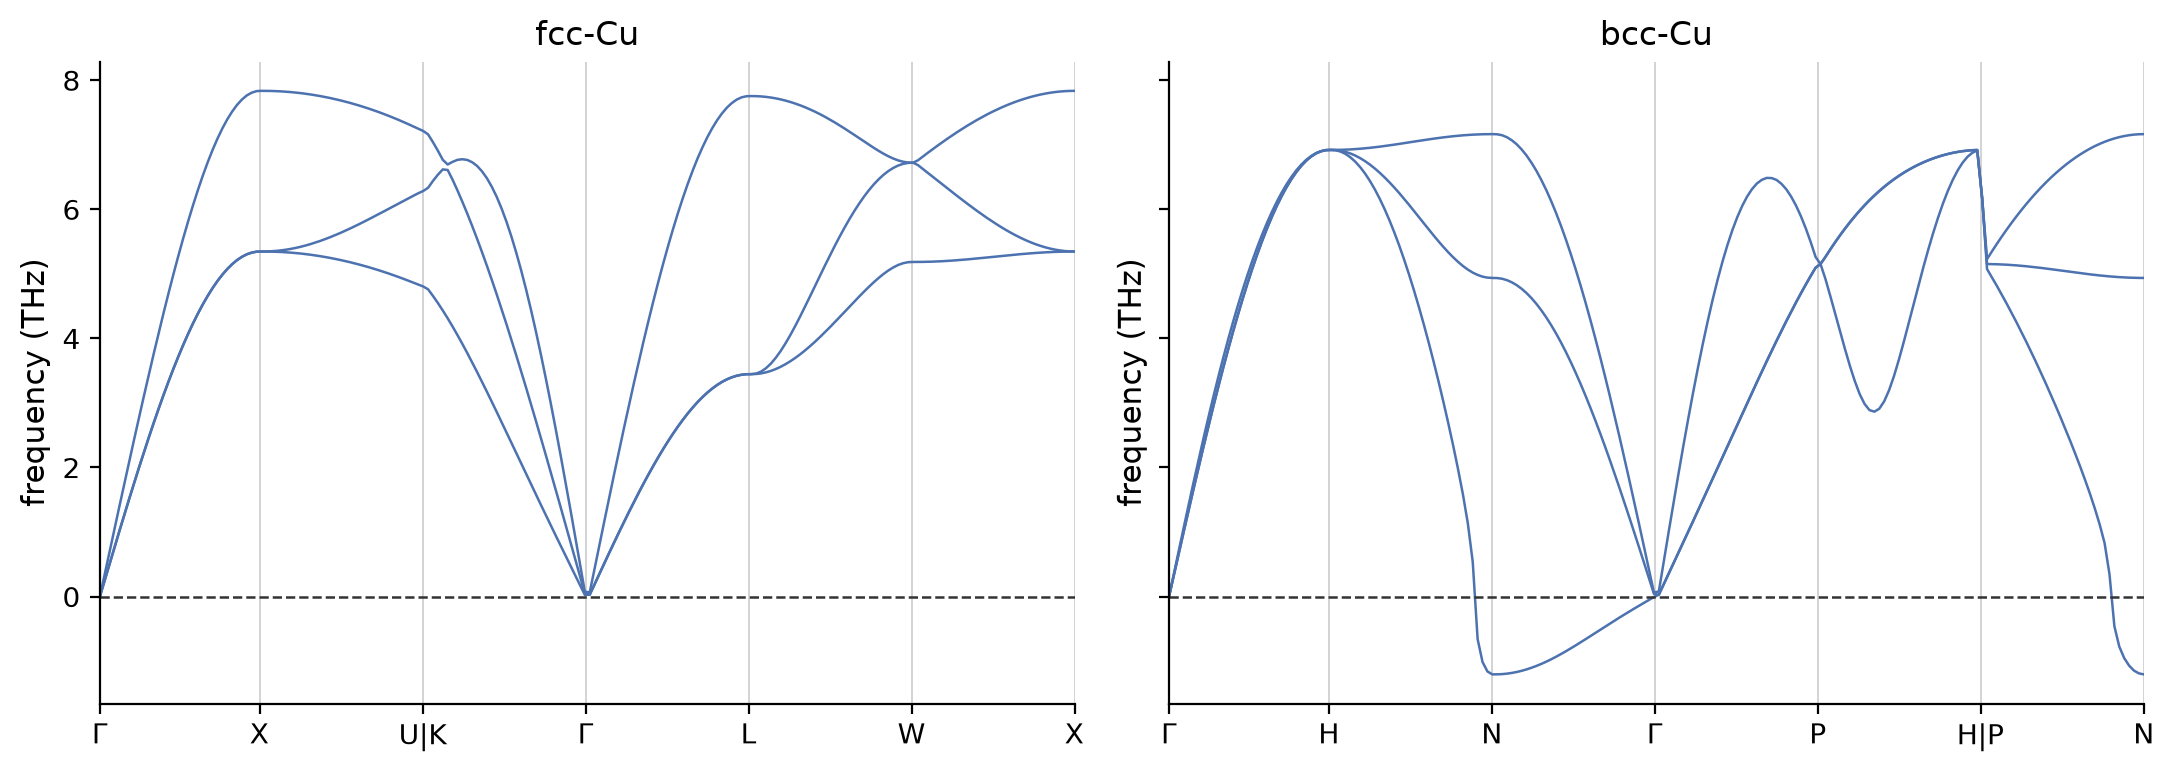

In [29]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, name in zip(axes, ["fcc-Cu", "bcc-Cu"]):
        mv.pl.bands(ph, materials=[name],
                    labels=ph.uns["path_labels"][name], ax=ax)
        ax.set_title(name)
    fig.tight_layout()
except (ImportError, NameError):
    print("needs phonopy, seekpath and matplotlib")

The dashed line at zero is where `mv.pl.bands` would normally draw the Fermi
level. On a phonon spectrum it marks exactly the right thing: below it is
imaginary. bcc copper goes under at **N**, bottoming at -1.2 THz — the N-point
instability that is the standard reason bcc is not what copper does.

## Screening

`mv.screen.filter` takes criteria as `column__operator=value` and **deposits** a
boolean column plus the criteria that produced it, rather than returning a
shorter list — because which criterion a candidate failed is a result.

In [30]:
mv.screen.filter(metals,
                 thermal_conductivity_emt__gt=3.0,
                 bulk_modulus_emt__gt=50.0,
                 name="conductive_and_stiff")

metals.uns["screens"]["conductive_and_stiff"]

{'criteria': {'thermal_conductivity_emt__gt': 3.0,
  'bulk_modulus_emt__gt': 50.0},
 'n_pass': 4,
 'n_total': 7}

In [31]:
metals.obs[["name", "thermal_conductivity_emt", "bulk_modulus_emt",
            "conductive_and_stiff"]].round(1)

,name,thermal_conductivity_emt,bulk_modulus_emt,conductive_and_stiff
0,Al,8.3,39.7,False
1,Cu,11.3,134.8,True
2,Ni,28.2,175.7,True
3,Ag,4.4,100.4,True
4,Au,1.4,174.3,False
5,Pd,4.9,179.4,True
6,Pt,3.0,278.4,False


Subset when you actually want the short list — the object is an ordinary
AnnData, so `metals[metals.obs['conductive_and_stiff']]` works and carries
everything with it.

## Which chemistry passed?

The question that follows every screen. Because `X` is the composition matrix,
this is `rank_genes_groups` with the nouns changed.

In [32]:
mv.tl.rank_elements_groups(metals, "conductive_and_stiff")

metals.uns["rank_elements_groups"]["True"][
    ["element", "n_in_group", "frac_in_group", "odds_ratio", "pval"]]

,element,n_in_group,frac_in_group,odds_ratio,pval
0,Al,0,0.00,0.0,0.428571
1,Pt,0,0.00,0.0,0.428571
2,Au,0,0.00,0.0,0.428571
3,Ni,1,0.25,inf,1.000000
4,Cu,1,0.25,inf,1.000000
5,Pd,1,0.25,inf,1.000000
6,Ag,1,0.25,inf,1.000000


With seven elementals this is a formality. On a library of thousands it is the
operation that turns a pass/fail column into a statement about chemistry, and it
is the reason `X` holds composition rather than being left empty.

## What the object remembers

In [33]:
for step in mv.provenance(metals):
    print(step)

data.from_structures
pp.describe(source='input')
calc.relax(level='emt', source='input', fmax=0.02, cell=True, key_added='relaxed_emt')
prop.elastic(level='emt', source='relaxed_emt', strain=0.01)
prop.phonon(level='emt', source='relaxed_emt', supercell=[1, 1, 1])
prop.thermal_conductivity(level='emt', temperature=300.0)
prop.eos(level='emt', source='relaxed_emt', model='birch_murnaghan', n_scales=7)
prop.quasiharmonic(level='emt', source='relaxed_emt', t_min=300.0, t_max=900, eos_model='vinet')
prop.free_energy(level='emt', temperature=300.0)
prop.phonon(level='emt', source='relaxed_emt', supercell=[2, 2, 2])
prop.free_energy(level='emt', temperature=300.0)
prop.phonon(level='emt', source='relaxed_emt', supercell=[2, 2, 2])
prop.free_energy(level='emt', temperature=300.0)
screen.filter(name='conductive_and_stiff', thermal_conductivity_emt__gt=3.0, bulk_modulus_emt__gt=50.0)
tl.rank_elements_groups(groupby='conductive_and_stiff', method='presence')


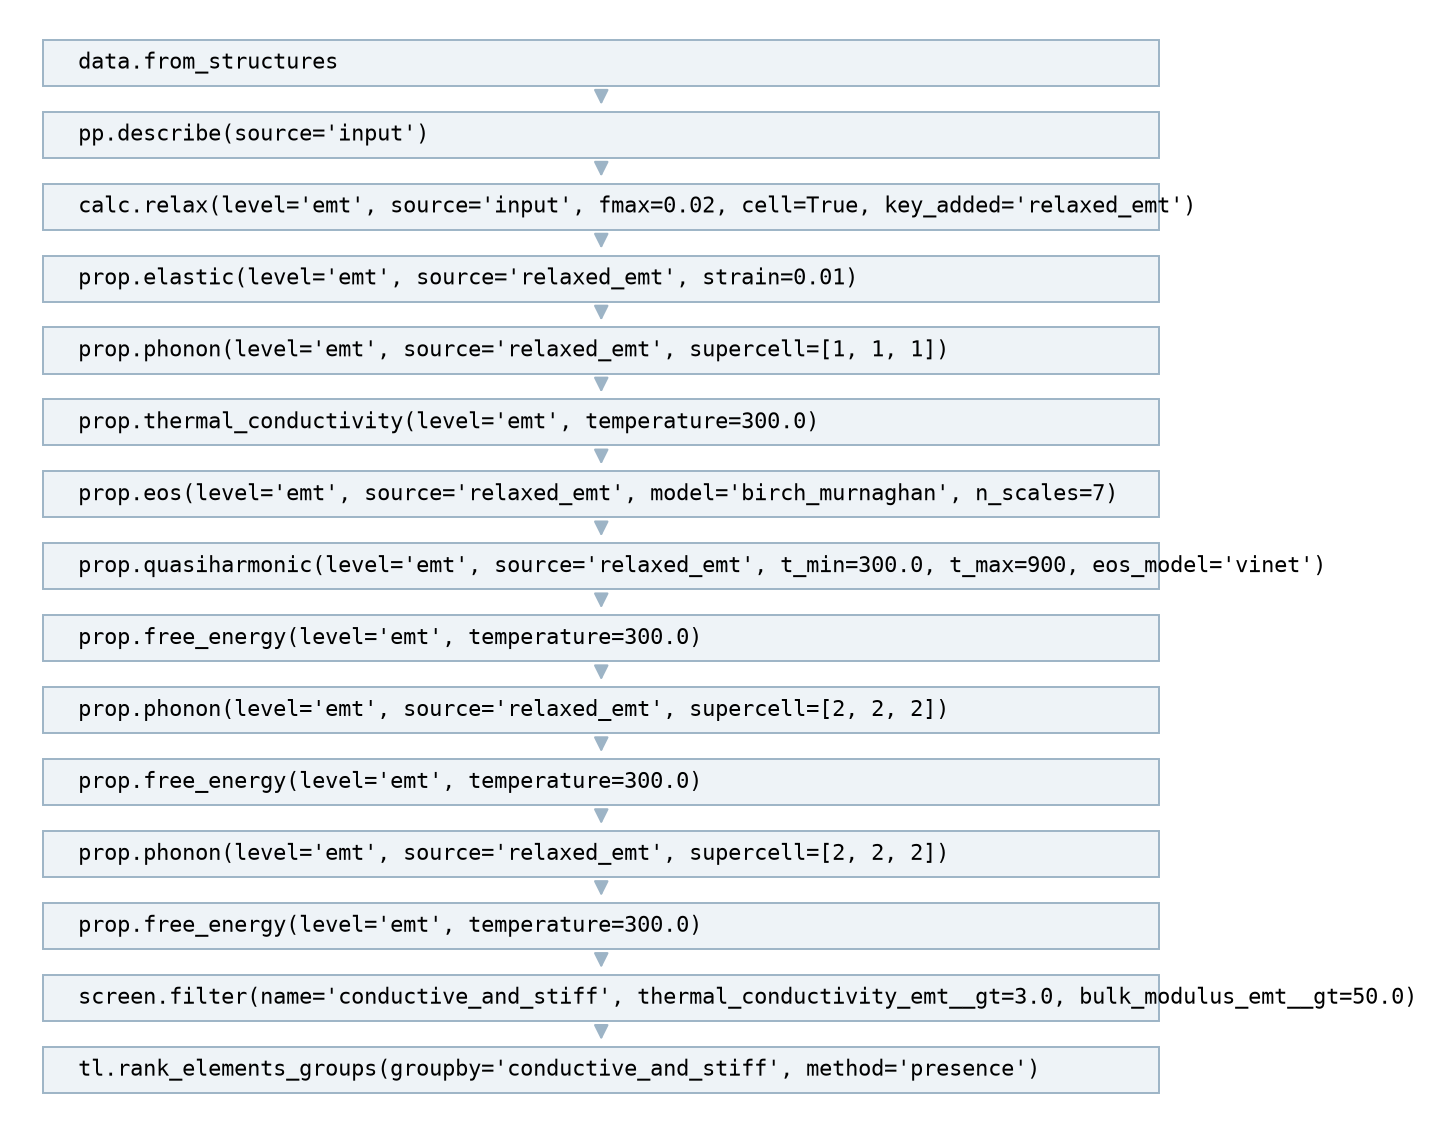

In [34]:
ax = mv.pl.provenance(metals)

Parameters are recorded with each call, so the history replays as code rather
than reading as a list of verbs. Saving keeps all of it:

```python
metals.write_h5ad("screen.h5ad")
```

Structures, descriptors, level records and provenance all survive, and the file
is an ordinary `h5ad` that anndata reads without matverse installed.

```{seealso}
[Screening, end to end](screening.ipynb) covers the same pipeline in more detail;
[Chemical space](chemical_space.ipynb) picks up where `rank_elements_groups` left
off; [Beyond one number](beyond_one_number.ipynb) covers curves, per-atom results
and measured data.
```